# 🛒 Blinkit Sales Analysis

## Project Objective
The objective of this project is to analyze Blinkit grocery sales data and identify important business insights such as sales trends, outlet performance, item categories, and customer preferences.

## Tools & Libraries Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Dataset Used
Blinkit Grocery Sales Dataset

In [1]:
# ==============================
# Importing Required Libraries
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

# Graph styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# 1. Data Loading

In [2]:
# ==============================
# Loading the Dataset
# ==============================

df = pd.read_excel(r"C:\Users\user\Downloads\BlinkIT Grocery Data.csv.xlsx")

# Display first 5 rows
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


# 2. Dataset Overview

In [3]:
# ==============================
# Dataset Overview
# ==============================

# First 5 rows
print("First 5 Rows:")
display(df.head())

# Shape of dataset
print("Shape of Dataset:")
print(df.shape)

# Column names
print("Column Names:")
print(df.columns)

# Dataset Information
print("Dataset Information:")
df.info()

# Statistical Summary
print("Statistical Summary:")
display(df.describe())

First 5 Rows:


,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


Shape of Dataset:
(8523, 12)
Column Names:
Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2016.450546,0.066132,12.857645,140.992783,3.965857
std,3.189396,0.051598,4.643456,62.275067,0.605651
min,2011.000000,0.000000,4.555000,31.290000,1.000000
25%,2014.000000,0.026989,8.773750,93.826500,4.000000
50%,2016.000000,0.053931,12.600000,143.012800,4.000000
75%,2018.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


# 3. Missing Values Analysis

In [4]:
# ==============================
# Checking Missing Values
# ==============================

# Count missing values in each column
missing_values = df.isnull().sum()

print("Missing Values in Dataset:")
print(missing_values)

Missing Values in Dataset:
Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64


# 4. Handling Missing Values

In [5]:
# ==============================
# Handling Missing Values
# ==============================

# Fill missing values in Item Weight using mean
df['Item Weight'] = df['Item Weight'].fillna(df['Item Weight'].mean())

# Check again for missing values
print("Missing Values After Handling:")
print(df.isnull().sum())

Missing Values After Handling:
Item Fat Content             0
Item Identifier              0
Item Type                    0
Outlet Establishment Year    0
Outlet Identifier            0
Outlet Location Type         0
Outlet Size                  0
Outlet Type                  0
Item Visibility              0
Item Weight                  0
Sales                        0
Rating                       0
dtype: int64


# 5. Data Cleaning

In [6]:
# ==============================
# Checking Duplicate Values
# ==============================

# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


# 6. Exploratory Data Analysis (EDA)

## Distribution of Item Types

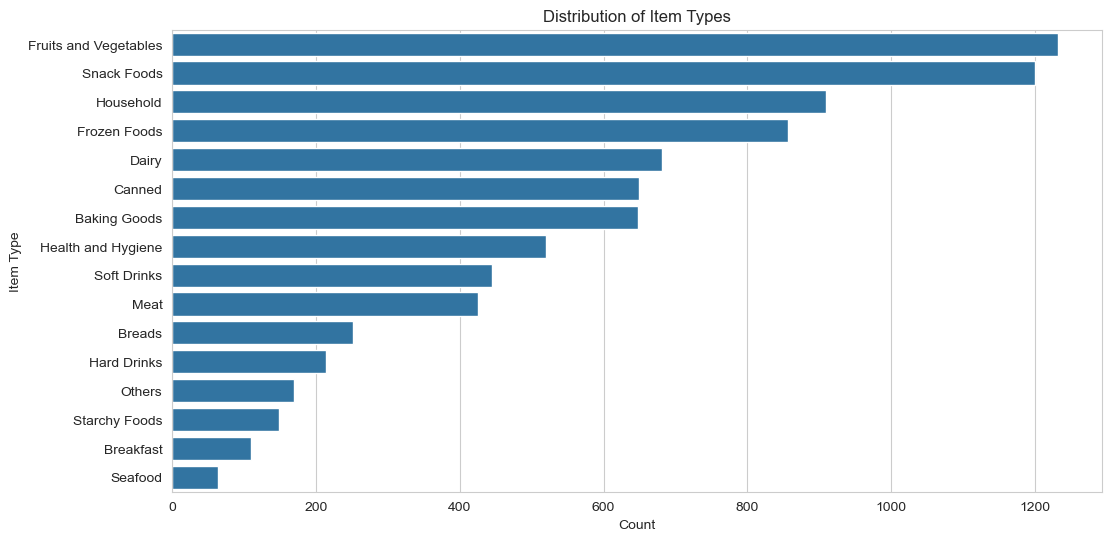

In [7]:
# ==============================
# Distribution of Item Types
# ==============================

plt.figure(figsize=(12,6))

sns.countplot(
    y='Item Type',
    data=df,
    order=df['Item Type'].value_counts().index
)

plt.title('Distribution of Item Types')
plt.xlabel('Count')
plt.ylabel('Item Type')

plt.show()

### Insight:
- Some item categories appear more frequently in the dataset.
- High frequency categories may indicate popular products in Blinkit.
- Low frequency categories have lesser representation.

## Sales by Item Type

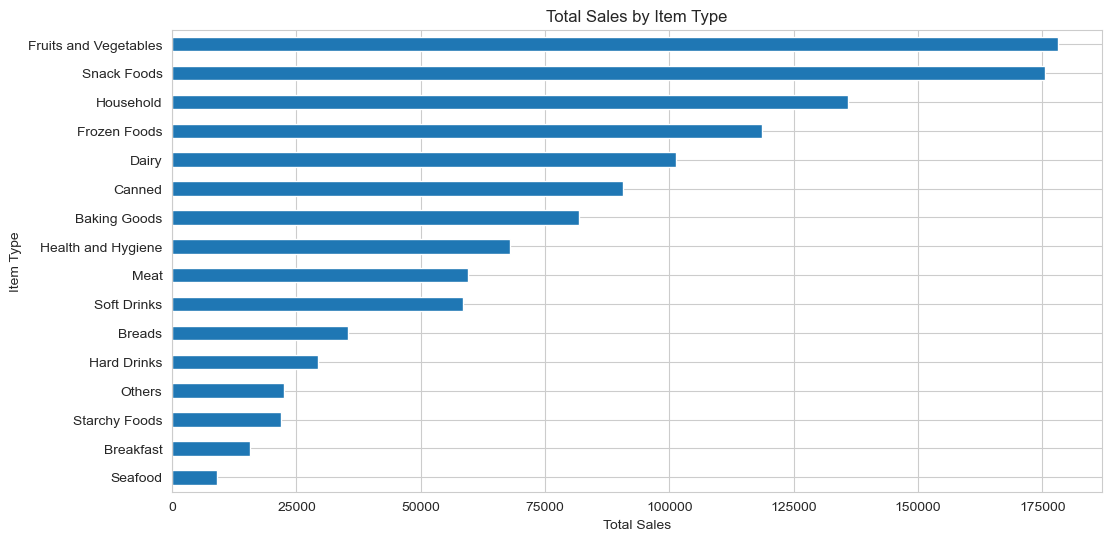

In [8]:
# ==============================
# Sales by Item Type
# ==============================

plt.figure(figsize=(12,6))

sales_by_item = df.groupby('Item Type')['Sales'].sum().sort_values()

sales_by_item.plot(kind='barh')

plt.title('Total Sales by Item Type')
plt.xlabel('Total Sales')
plt.ylabel('Item Type')

plt.show()

### Insight:
- Some item categories contribute significantly higher sales than others.
- High-performing item types indicate strong customer demand.
- Low-performing categories contribute less to total sales.

## Sales by Outlet Type

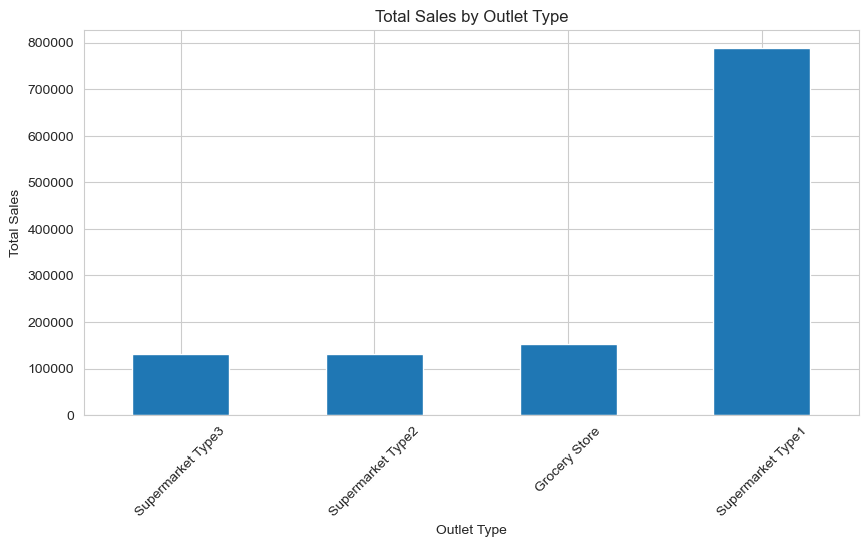

In [9]:
# ==============================
# Sales by Outlet Type
# ==============================

plt.figure(figsize=(10,5))

outlet_sales = df.groupby('Outlet Type')['Sales'].sum().sort_values()

outlet_sales.plot(kind='bar')

plt.title('Total Sales by Outlet Type')
plt.xlabel('Outlet Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

### Insight:
- Different outlet types contribute differently to total sales.
- Some outlet types perform significantly better than others.
- High-sales outlet types may indicate stronger customer preference.

## Rating vs Sales

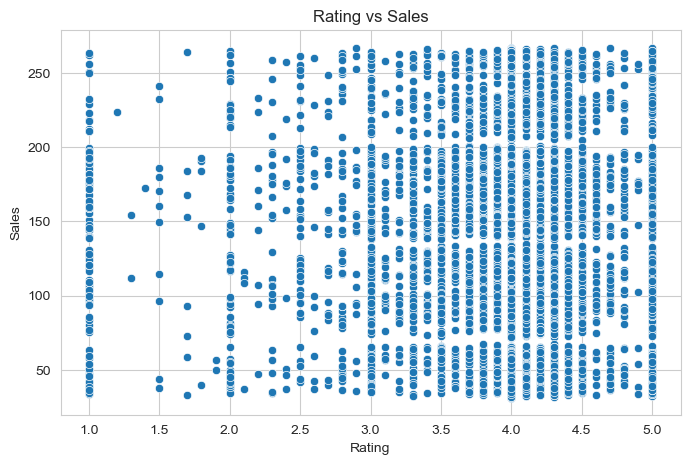

In [10]:
# ==============================
# Rating vs Sales
# ==============================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Rating',
    y='Sales',
    data=df
)

plt.title('Rating vs Sales')
plt.xlabel('Rating')
plt.ylabel('Sales')

plt.show()

### Insight:
- The graph shows the relationship between ratings and sales.
- Products with higher ratings may influence customer purchasing behavior.
- Sales vary across different rating levels.

## Correlation Heatmap

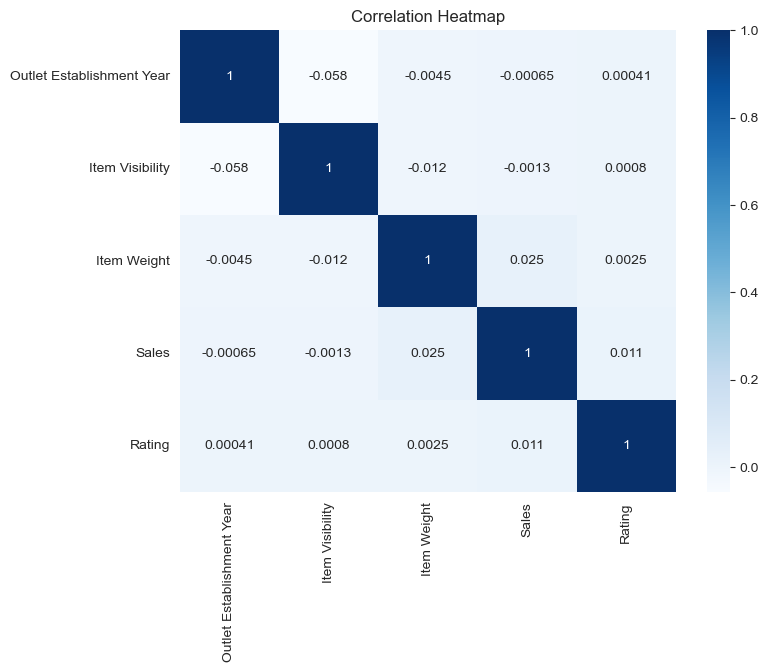

In [11]:
# ==============================
# Correlation Heatmap
# ==============================

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Heatmap')

plt.show()

### Insight:
- The heatmap shows relationships between numerical features.
- Strong positive correlation indicates variables increasing together.
- Weak correlation means little relationship between variables.

# 7. Conclusion

From the Blinkit sales analysis, several important business insights were identified:

- The dataset was cleaned successfully by handling missing values.
- Different item categories contributed differently to total sales.
- Certain outlet types generated higher sales compared to others.
- Product ratings showed some relationship with sales performance.
- Data visualization helped in understanding customer preferences and outlet performance.

Overall, this analysis provides meaningful insights that can help improve business decisions and sales strategies in Blinkit.